# FIP 09 — Task and movement regression models of DA and NE

`fip_08` §1 fits DA and NE with a task model (FIR kernels for go cue, rewarded outcome, unrewarded
outcome and every lick) and asks how much variance lagged motion energy (ME) adds. This notebook
refits that regression with three task models, each with and without ME:

| model | task regressors |
|---|---|
| **events** | go cue, rewarded outcome, unrewarded outcome |
| **events + licks** | the above and every lick (`fip_08`'s task model) |
| **events + Q/RPE** | *events*, plus three trial-weighted kernels: go cue × Q_sum, rewarded outcome × RPE, unrewarded outcome × RPE |

ME lags run −1 to +4 s, the span of the task kernels (`fip_08` used −1 to +2 s; §2 compares the two).

For each model the questions are: how much DA and NE variance it explains; how much ME adds beyond it,
against ME circularly shifted; and, for the Q/RPE model, how much the trial values add beyond
the events, against the same values shuffled across trials, with and without ME.

**Data and conventions.** As in `fip_08`: the same-hemisphere DA/NE sessions of `fip_05`/`fip_07`
with bottom-camera ME, one 20 Hz grid, each signal z-scored over the session. R² is in sample; every
increment is set against a null fit with the same number of columns. Session values are averaged
within animal; tests are Wilcoxon signed-rank on animal means.

1. Variance explained by each model, with and without ME
2. What ME adds beyond each task model, and with ME lags −1…2 s vs −1…4 s
3. What licks add beyond the events, with and without ME
4. What Q_sum and RPE add, with and without ME, and their kernels
5. Each model in one session
6. Supplementary: every fitted kernel
7. Numbers

## Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.sparse import hstack

import fip_utils as fu
import signal_utils as su
import stats_utils as st
import plot_utils as pu
from plotstyle import apply_style, style_ax, save_fig, PALETTE, OKABE_ITO

apply_style()
warnings.filterwarnings("ignore", message="Mean of empty slice")
warnings.filterwarnings("ignore", message="Sample size too small for normal approximation")
warnings.filterwarnings("ignore", message="Exact p-value calculation does not work if there are zeros")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [2]:
IS_CO = os.path.isdir("/root/capsule")

ASSET_CANDIDATES = {
    "3ch": ["/root/capsule/data/DANE_3channels_curated",
            "../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f"],
    "4ch": ["/root/capsule/data/DANE_4channels_curated",
            "../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1"],
}
ME_DATA_ROOT = "/root/capsule/data" if IS_CO else os.environ.get("ME_DATA_ROOT", "../../data")
PAIRS_CACHE = ("/root/capsule/scratch/fip_05/pairs.pkl" if IS_CO
               else "../../data/fip_05_cache/pairs.pkl")
FIG_DIR = "/root/capsule/scratch/figures/fip" if IS_CO else "../data/figures/fip"
SAVE_FIG = True

# ── Data (as fip_08) ─────────────────────────────────────────────────────────
FS = 20.0                  # Hz, the common grid
CAMERA = "BottomCamera"
MIN_SESSIONS_PER_ANIMAL = 3
EXCLUDE_SUBJECTS = ()      # QC decides; none excluded

# ── Models ───────────────────────────────────────────────────────────────────
KERNEL_S = (-1.0, 4.0)     # task-event kernels (fip_05/fip_08)
ME_LAGS_S = (-1.0, 4.0)    # ME regressors: the signal may follow ME by up to 4 s, or lead it by 1 s
ME_LAGS_SHORT_S = (-1.0, 2.0)   # fip_08's ME span, compared in §2
RIDGE = 1e-3               # as fu.task_residuals
N_SHIFT_R2 = 10            # circular shifts of ME for the ME-increment null (fip_08)
MIN_SHIFT_S = 60.0         # smallest circular shift
N_PERM_Q = 10              # shuffles of the trial values for the Q/RPE-increment null

EVENTS_BASE = ["go cue", "rewarded outcome", "unrewarded outcome"]
VALUE_EVENTS = ["go cue × Q_sum", "rewarded outcome × RPE", "unrewarded outcome × RPE"]
MODELS = {
    "events": EVENTS_BASE,
    "events + licks": EVENTS_BASE + ["lick"],
    "events + Q/RPE": EVENTS_BASE + VALUE_EVENTS,
}
ALL_EVENTS = list(fu.TASK_EVENTS)      # the superset design: every model is a subset of its columns
assert all(e in ALL_EVENTS for evs in MODELS.values() for e in evs)

# ── Example session (§5) ─────────────────────────────────────────────────────
WIN_S = 30.0               # s shown

# ── Colors ───────────────────────────────────────────────────────────────────
SIG = ("da", "ne")
SIG_COLOR = {"da": OKABE_ITO["vermillion"], "ne": OKABE_ITO["blue"]}
SIG_LABEL = {"da": "DA (NAc dLight)", "ne": "NE (PL LC-axon GCaMP)"}
MODEL_COLOR = {"events": "0.25", "events + licks": OKABE_ITO["bluish_green"],
               "events + Q/RPE": OKABE_ITO["sky_blue"]}
ME_COLOR = OKABE_ITO["reddish_purple"]
NULL_COLOR = PALETTE["not_sig"]
EVENT_COLOR = {"go cue": OKABE_ITO["sky_blue"], "rewarded outcome": OKABE_ITO["orange"],
               "unrewarded outcome": "0.55", "lick": OKABE_ITO["bluish_green"]}
rng = np.random.default_rng(0)

## 0. Data

The sessions of `fip_08`: pairs from `fu.load_pairs` (cached), kept if the bottom camera passes the
ME screen. ME on the session clock (`fu.motion_energy_to_session`) is averaged onto the pair's 20 Hz
grid and z-scored.

In [3]:
asset_roots = {}
for name, cands in ASSET_CANDIDATES.items():
    root = fu.find_asset_root(cands)
    print(f"{name}: {root}")
    if root:
        asset_roots[name] = root

inv = fu.inventory_pairs(asset_roots)
kept, side_table = fu.choose_side(inv, MIN_SESSIONS_PER_ANIMAL)
all_pairs = fu.load_pairs(kept, fs=FS, cache_path=PAIRS_CACHE)
path_of = dict(zip(kept["session"], kept["path"]))
me_ok = set(fu.me_sessions(CAMERA, data_root=ME_DATA_ROOT))

pairs = []
for p in all_pairs:
    if p["session"] not in me_ok or p["subject"] in EXCLUDE_SUBJECTS:
        continue
    trials_raw = pd.read_parquet(os.path.join(path_of[p["session"]], "df_trials.parquet"))
    t_me, y, _ = fu.motion_energy_to_session(p["session"], trials_raw, camera=CAMERA,
                                             data_root=ME_DATA_ROOT)
    q = dict(p)
    q["z"] = {"da": su.zscore(p["da"]), "ne": su.zscore(p["ne"]),
              "me": np.nan_to_num(su.zscore(su.bin_to_grid(t_me, y, p["t0"], FS, len(p["da"]))))}
    pairs.append(q)

SUBJECTS = sorted({p["subject"] for p in pairs})
N_ANIMALS = len(SUBJECTS)
print(f"{len(pairs)} of {len(all_pairs)} sessions have bottom-camera ME; {N_ANIMALS} animals")
pd.Series([p["subject"] for p in pairs]).value_counts().sort_index().rename("sessions").to_frame().T

3ch: ../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f
4ch: ../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1/data


loaded 97 pairs from cache ../../data/fip_05_cache/pairs.pkl


88 of 97 sessions have bottom-camera ME; 9 animals


,800886,808054,809487,809491,815334,816212,816214,818585,818586
sessions,4,15,8,19,3,5,5,7,22


### The fits

Each sample of the signal is predicted as

$$\hat y(t) = b_0 + \sum_{e}\sum_{\ell = -1\,\mathrm{s}}^{+3.95\,\mathrm{s}} k_e(\ell)\,w_{e,i}\,[\text{event } e \text{ of trial } i \text{ at } t - \ell] + \sum_{L = -1\,\mathrm{s}}^{+4\,\mathrm{s}} m(L)\, \mathrm{ME}(t - L)$$

with $w_{e,i} = 1$ for the plain events. For the three trial-weighted events, $w_{e,i}$ is the trial's value
centred within the session: Q_sum at each go cue (no-response trials, where the behavioral model
leaves Q_sum empty, get weight 0), and `RPE_earned` at each outcome, centred within the rewarded and
within the unrewarded trials (RPE there is $1 - Q_\text{chosen}$ and $-Q_\text{chosen}$). Their kernels are
the response per unit of Q_sum or RPE *on top of* the plain go-cue or outcome kernel, which stays in
the model. This is `fu.event_design` with events from `fu.task_events`.

All seven event blocks, the intercept and the ME lags go into one design matrix per session, and every
model is a set of its columns. The normal equations ($X^\top X$, $X^\top y$) are built once and each model solved
on its rows and columns, with `fu.task_residuals`' small ridge. The −1…2 s ME span is a subset of the
−1…4 s columns. Two nulls:

- **ME shifted.** ME circularly shifted by ≥ 60 s (10 shifts), refit. This breaks ME's alignment and
  keeps its autocorrelation, so the median null increment is what the extra columns add by chance.
- **Q/RPE shuffled.** The trial values permuted among their trials (Q_sum among all trials, RPE within
  each outcome class; 10 shuffles), refit. This keeps event times and the value distribution.

In [4]:
N_K = int(round(KERNEL_S[1] * FS)) - int(round(KERNEL_S[0] * FS))
KERNEL_T = np.arange(int(round(KERNEL_S[0] * FS)), int(round(KERNEL_S[1] * FS))) / FS
ME_T = np.arange(int(round(ME_LAGS_S[0] * FS)), int(round(ME_LAGS_S[1] * FS)) + 1) / FS
N_EV = len(ALL_EVENTS)
I_INTERCEPT = N_EV * N_K
ME_COLS = I_INTERCEPT + 1 + np.arange(len(ME_T))
ME_SHORT_COLS = ME_COLS[(ME_T >= ME_LAGS_SHORT_S[0] - 1e-9) & (ME_T <= ME_LAGS_SHORT_S[1] + 1e-9)]
VALUE_BLOCK = np.concatenate([np.arange(ALL_EVENTS.index(e) * N_K, (ALL_EVENTS.index(e) + 1) * N_K)
                              for e in VALUE_EVENTS])


def task_cols(events):
    # superset columns of these event blocks, then the intercept
    return np.r_[np.concatenate([np.arange(ALL_EVENTS.index(e) * N_K, (ALL_EVENTS.index(e) + 1) * N_K)
                                 for e in events]), I_INTERCEPT]


def design(p, value_rng=None):
    # sparse superset of event blocks + intercept; value_rng shuffles the trial values
    return fu.event_design(p, KERNEL_S, fu.task_events(p, ALL_EVENTS, rng=value_rng))


def normal_eqs(S, M, ys):
    # X'X and X'y for X = [S | M]
    StM = np.asarray(S.T @ M)
    G = np.block([[(S.T @ S).toarray(), StM], [StM.T, M.T @ M]])
    b = {s: np.r_[S.T @ y, M.T @ y] for s, y in ys.items()}
    return G, b


def solve(G, b, y, cols):
    # ridge solution on a column subset; R² from the exact residual sum of squares
    Gs = G[np.ix_(cols, cols)]
    beta = np.linalg.solve(Gs + RIDGE * np.eye(len(cols)), b[cols])
    rss = y @ y - 2 * beta @ b[cols] + beta @ Gs @ beta
    tss = y @ y - len(y) * y.mean() ** 2
    return beta, 1.0 - rss / tss


def all_r2(G, b, ys, with_short=True):
    # R² of every model with and without ME, and ME alone, for both signals
    out = {}
    for s, y in ys.items():
        for m, evs in MODELS.items():
            tc = task_cols(evs)
            out[(s, m, "task")] = solve(G, b[s], y, tc)[1]
            out[(s, m, "me")] = solve(G, b[s], y, np.r_[tc, ME_COLS])[1]
            if with_short:
                out[(s, m, "me_short")] = solve(G, b[s], y, np.r_[tc, ME_SHORT_COLS])[1]
        out[(s, "ME only", "me")] = solve(G, b[s], y, np.r_[I_INTERCEPT, ME_COLS])[1]
        out[(s, "ME only", "me_short")] = solve(G, b[s], y, np.r_[I_INTERCEPT, ME_SHORT_COLS])[1]
    return out

In [5]:
r2_rows, beta_rows = [], []
for i, p in enumerate(pairs):
    ys = {s: p["z"][s].astype(float) for s in SIG}
    n = len(ys["da"])
    S = design(p)
    M = fu.lagged_columns(p["z"]["me"], FS, ME_LAGS_S)
    G, b = normal_eqs(S, M, ys)
    obs = all_r2(G, b, ys)

    # null 1: ME circularly shifted (task blocks unchanged)
    me_null = []
    for shift in rng.integers(int(MIN_SHIFT_S * FS), n - int(MIN_SHIFT_S * FS), N_SHIFT_R2):
        Gn, bn = normal_eqs(S, fu.lagged_columns(np.roll(p["z"]["me"], shift), FS, ME_LAGS_S), ys)
        me_null.append(all_r2(Gn, bn, ys))
    # null 2: trial values shuffled across trials (ME unchanged)
    q_null = []
    for _ in range(N_PERM_Q):
        Gn, bn = normal_eqs(design(p, value_rng=rng), M, ys)
        q_null.append(all_r2(Gn, bn, ys, with_short=False))

    r = dict(subject=p["subject"], session=p["session"])
    for s in SIG:
        for m in MODELS:
            r[f"{s}|{m}"] = obs[(s, m, "task")]
            r[f"{s}|{m} + ME"] = obs[(s, m, "me")]
            for span, key in (("", "me"), (" short", "me_short")):
                add = obs[(s, m, key)] - obs[(s, m, "task")]
                null = np.median([d[(s, m, key)] - d[(s, m, "task")] for d in me_null])
                r[f"{s}|ME added to {m}{span}"] = add
                r[f"{s}|ME added to {m}{span} null"] = null
                r[f"{s}|ME added to {m}{span} vs null"] = add - null
        r[f"{s}|ME only"] = obs[(s, "ME only", "me")]
        r[f"{s}|ME only short"] = obs[(s, "ME only", "me_short")]
        # licks beyond the events, without and with ME
        r[f"{s}|licks added"] = obs[(s, "events + licks", "task")] - obs[(s, "events", "task")]
        r[f"{s}|licks added with ME"] = obs[(s, "events + licks", "me")] - obs[(s, "events", "me")]
        # Q/RPE beyond the events, without and with ME, each against shuffled values
        for key, lab in (("task", ""), ("me", " with ME")):
            add = obs[(s, "events + Q/RPE", key)] - obs[(s, "events", key)]
            null = np.median([d[(s, "events + Q/RPE", key)] - d[(s, "events", key)] for d in q_null])
            r[f"{s}|Q/RPE added{lab}"] = add
            r[f"{s}|Q/RPE added{lab} null"] = null
            r[f"{s}|Q/RPE added{lab} vs null"] = add - null
    r2_rows.append(r)

    # coefficients of every model, with and without ME
    br = dict(subject=p["subject"], session=p["session"])
    for s in SIG:
        for m, evs in MODELS.items():
            tc = task_cols(evs)
            br[(s, m, "task")] = solve(G, b[s], ys[s], tc)[0]
            br[(s, m, "me")] = solve(G, b[s], ys[s], np.r_[tc, ME_COLS])[0]
    beta_rows.append(br)
    if (i + 1) % 10 == 0:
        print(f"  {i + 1} / {len(pairs)}")

r2_sess = pd.DataFrame(r2_rows)
r2_animal = st.animal_means(r2_sess, [c for c in r2_sess if c not in ("subject", "session")],
                            by_session=False)
print(f"fit {len(r2_sess)} sessions")

  10 / 88


  20 / 88


  30 / 88


  40 / 88


  50 / 88


  60 / 88


  70 / 88


  80 / 88


fit 88 sessions


In [6]:
# check: the events + licks fits reproduce fip_08's fu.task_residuals on the first session
p0 = pairs[0]
ref_task = fu.task_residuals(p0, KERNEL_S)
ref_me = fu.task_residuals(p0, KERNEL_S, extra=fu.lagged_columns(p0["z"]["me"], FS, ME_LAGS_S))
for s in SIG:
    assert np.isclose(r2_sess.loc[0, f"{s}|events + licks"], ref_task[f"{s}_r2"], atol=1e-6)
    assert np.isclose(r2_sess.loc[0, f"{s}|events + licks + ME"], ref_me[f"{s}_r2"], atol=1e-6)
    assert np.allclose(beta_rows[0][(s, "events + licks", "me")], ref_me[f"{s}_beta"], atol=1e-6)
print("matches fu.task_residuals")

matches fu.task_residuals


In [7]:
def split_beta(beta, events):
    # {event: kernel, 'intercept': b0, 'ME': filter} from a coefficient vector of task_cols(events) (+ ME)
    k = {e: beta[j * N_K:(j + 1) * N_K] for j, e in enumerate(events)}
    k["intercept"] = beta[len(events) * N_K]
    if len(beta) > len(events) * N_K + 1:
        k["ME"] = beta[len(events) * N_K + 1:]
    return k


def animal_kernels(sig, model, fit, name):
    # (n_animals, n_lags) kernel of one regressor, session kernels averaged within animal
    ks = [split_beta(br[(sig, model, fit)], MODELS[model]) for br in beta_rows]
    if name not in ks[0]:
        return None
    return st.group_means([k[name] for k in ks], [br["subject"] for br in beta_rows])[1]


def report(title, df, cols):
    # mean ± SEM over animals and Wilcoxon p against zero, one row per column of an animal table
    rows = []
    for c in cols:
        m, p, n = st.wilcoxon_animals(df[c])
        rows.append(dict(measure=c, mean=m, sem=df[c].std(ddof=1) / np.sqrt(df[c].notna().sum()),
                         p=p, n=n))
    print(f"── {title}")
    print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3g}"))
    print()

## 1. Variance explained by each model

R² of DA and NE under each task model alone and with lagged ME (−1…4 s), and under ME alone. One
point per animal; the bar is the mean over animals.

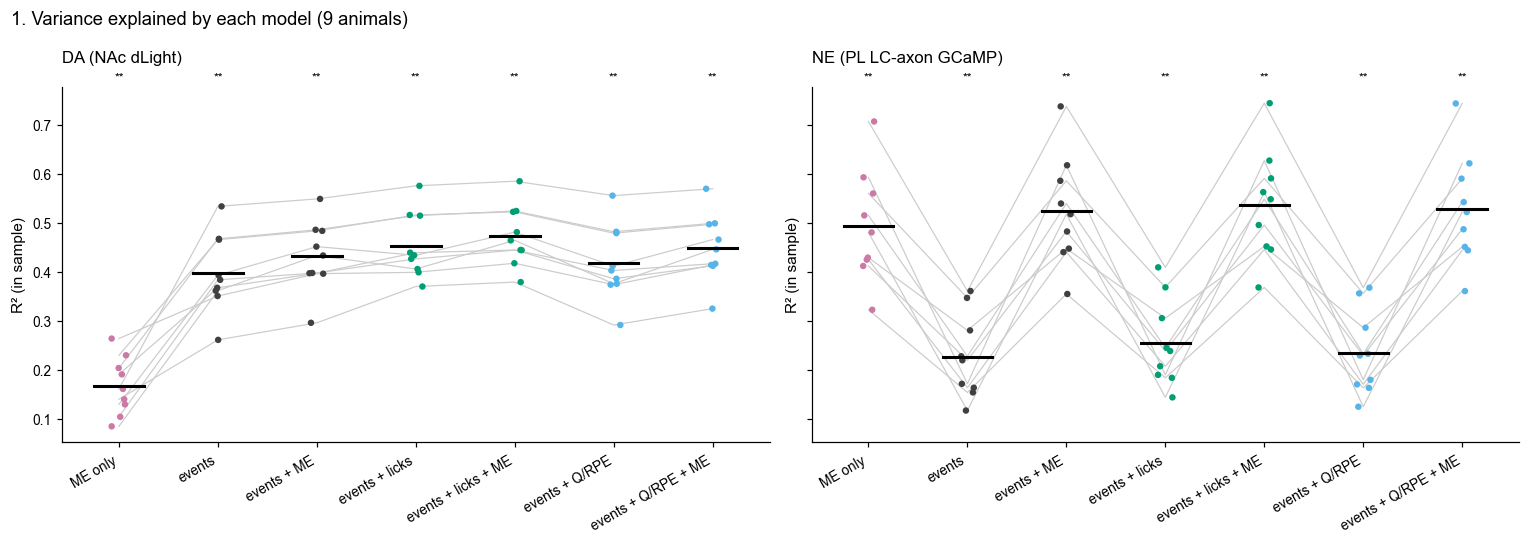

── DA R²
               measure  mean    sem       p  n
            da|ME only 0.167 0.0198 0.00391  9
             da|events 0.398 0.0267 0.00391  9
        da|events + ME 0.432 0.0241 0.00391  9
     da|events + licks 0.453 0.0224 0.00391  9
da|events + licks + ME 0.474 0.0209 0.00391  9
     da|events + Q/RPE 0.417 0.0258 0.00391  9
da|events + Q/RPE + ME 0.449 0.0232 0.00391  9

── NE R²
               measure  mean    sem       p  n
            ne|ME only 0.494 0.0383 0.00391  9
             ne|events 0.226 0.0288 0.00391  9
        ne|events + ME 0.525 0.0376 0.00391  9
     ne|events + licks 0.254 0.0297 0.00391  9
ne|events + licks + ME 0.537 0.0374 0.00391  9
     ne|events + Q/RPE 0.234 0.0288 0.00391  9
ne|events + Q/RPE + ME 0.529 0.0377 0.00391  9



In [8]:
R2_COLS = ["ME only"] + [c for m in MODELS for c in (m, f"{m} + ME")]
R2_COLORS = [ME_COLOR] + [MODEL_COLOR[m] for m in MODELS for _ in range(2)]
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, s in zip(axes, SIG):
    pu.strip_by_measure(ax, r2_animal, [f"{s}|{c}" for c in R2_COLS], R2_COLS, R2_COLORS,
                        "R² (in sample)", title=SIG_LABEL[s], zero=False, rng=rng)
    ax.title.set_color(SIG_COLOR[s])
fig.suptitle(f"1. Variance explained by each model ({N_ANIMALS} animals)", x=0.01, ha="left")
fig.tight_layout()
save_fig(fig, "fip_09_1_r2", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()
for s in SIG:
    report(f"{s.upper()} R²", r2_animal, [f"{s}|{c}" for c in R2_COLS])

## 2. What ME adds beyond each task model

ΔR² from adding lagged ME to each task model, minus the median of the same increment with ME
circularly shifted. **a–b** ME lags −1…4 s (this notebook); **c–d** −1…2 s (`fip_08`). The column for
*events + licks* at −1…2 s is `fip_08` §1's number.

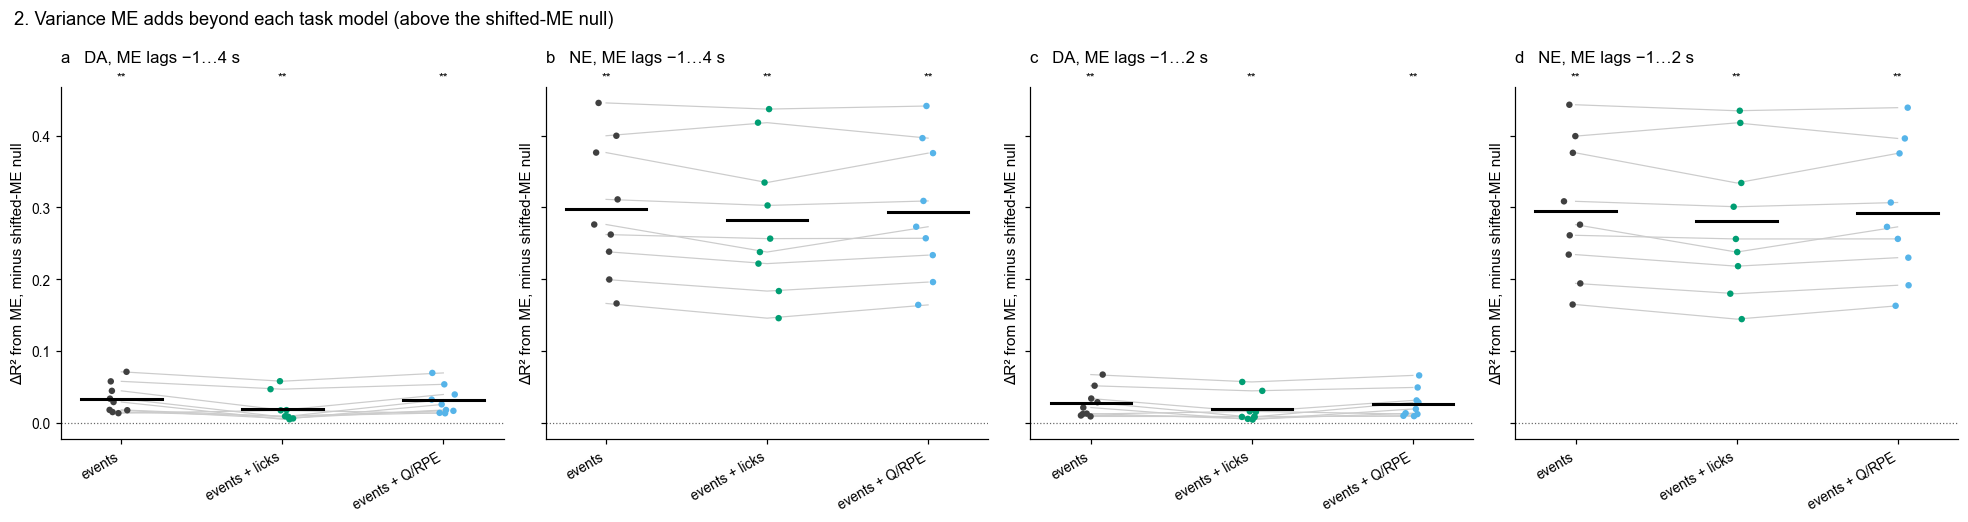

── DA ΔR² from ME
                                    measure     mean      sem       p  n
                      da|ME added to events    0.034   0.0069 0.00391  9
                 da|ME added to events null 0.000927 9.79e-05 0.00391  9
              da|ME added to events vs null   0.0331  0.00686 0.00391  9
              da|ME added to events + licks   0.0202  0.00644 0.00391  9
         da|ME added to events + licks null 0.000787 6.71e-05 0.00391  9
      da|ME added to events + licks vs null   0.0195  0.00643 0.00391  9
              da|ME added to events + Q/RPE    0.032  0.00659 0.00391  9
         da|ME added to events + Q/RPE null 0.000858 9.18e-05 0.00391  9
      da|ME added to events + Q/RPE vs null   0.0311  0.00654 0.00391  9
                da|ME added to events short   0.0278  0.00683 0.00391  9
           da|ME added to events short null 0.000571 6.39e-05 0.00391  9
        da|ME added to events short vs null   0.0272  0.00681 0.00391  9
        da|ME added to events + l

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.8), sharey=True)
for k, (span, span_lab) in enumerate((("", "−1…4 s"), (" short", "−1…2 s"))):
    for j, s in enumerate(SIG):
        ax = axes[2 * k + j]
        pu.strip_by_measure(ax, r2_animal, [f"{s}|ME added to {m}{span} vs null" for m in MODELS],
                            list(MODELS), [MODEL_COLOR[m] for m in MODELS],
                            "ΔR² from ME, minus shifted-ME null",
                            title=f"{'abcd'[2 * k + j]}   {s.upper()}, ME lags {span_lab}", rng=rng)
        ax.title.set_color(SIG_COLOR[s])
fig.suptitle("2. Variance ME adds beyond each task model (above the shifted-ME null)", x=0.01, ha="left")
fig.tight_layout()
save_fig(fig, "fip_09_2_me_added", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()
for s in SIG:
    report(f"{s.upper()} ΔR² from ME", r2_animal,
           [f"{s}|ME added to {m}{span}{suf}" for span in ("", " short") for m in MODELS
            for suf in ("", " null", " vs null")])

## 3. What licks add beyond the events

ΔR² of *events + licks* over *events*, without ME and with ME (−1…4 s) in both. The lick kernels add
100 columns. This has no null; ME's shifted null in §2 gives the chance increment for a 101-column
block of an autocorrelated regressor.

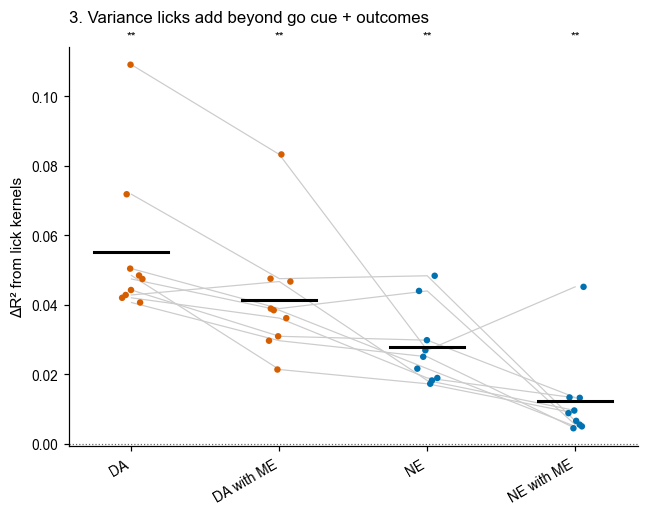

── ΔR² from licks
               measure   mean     sem       p  n
        da|licks added 0.0552 0.00742 0.00391  9
da|licks added with ME 0.0414  0.0059 0.00391  9
        ne|licks added 0.0278 0.00376 0.00391  9
ne|licks added with ME 0.0124 0.00424 0.00391  9



In [10]:
fig, ax = plt.subplots(figsize=(6, 4.8))
cols = [f"{s}|licks added{w}" for s in SIG for w in ("", " with ME")]
pu.strip_by_measure(ax, r2_animal, cols, [f"{s.upper()}{w}" for s in SIG for w in ("", " with ME")],
                    [SIG_COLOR[s] for s in SIG for _ in range(2)], "ΔR² from lick kernels",
                    title="3. Variance licks add beyond go cue + outcomes", rng=rng)
fig.tight_layout()
save_fig(fig, "fip_09_3_licks_added", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()
report("ΔR² from licks", r2_animal, cols)

## 4. Q_sum and RPE

**a.** ΔR² of *events + Q/RPE* over *events*, minus the median of the same increment with the trial
values shuffled, without and with ME. **b–d.** The trial-weighted kernels: the response per unit of
Q_sum at the go cue, and per unit of RPE at a rewarded and at an unrewarded outcome (mean ± SEM
over animals; solid: without ME; dashed: with ME).

**The three kernels are not separately interpretable.** Within an outcome class RPE is a constant
minus Q_chosen, and Q_chosen moves with Q_sum (on rewarded trials Q_sum and RPE correlate at about
−0.9 within a session). The Q_sum-weighted go cue and the RPE-weighted outcome come ~0.3 s apart, so
the fit can trade one kernel against the other. On a quarter of the sessions, fitted alone, the DA RPE
kernel (0–2 s) is positive (+0.40 rewarded, +0.14 unrewarded) and the Q_sum kernel negative (−0.32);
fitted together, both DA RPE kernels turn negative. Panel **a** is unaffected: it is the variance of the three together.

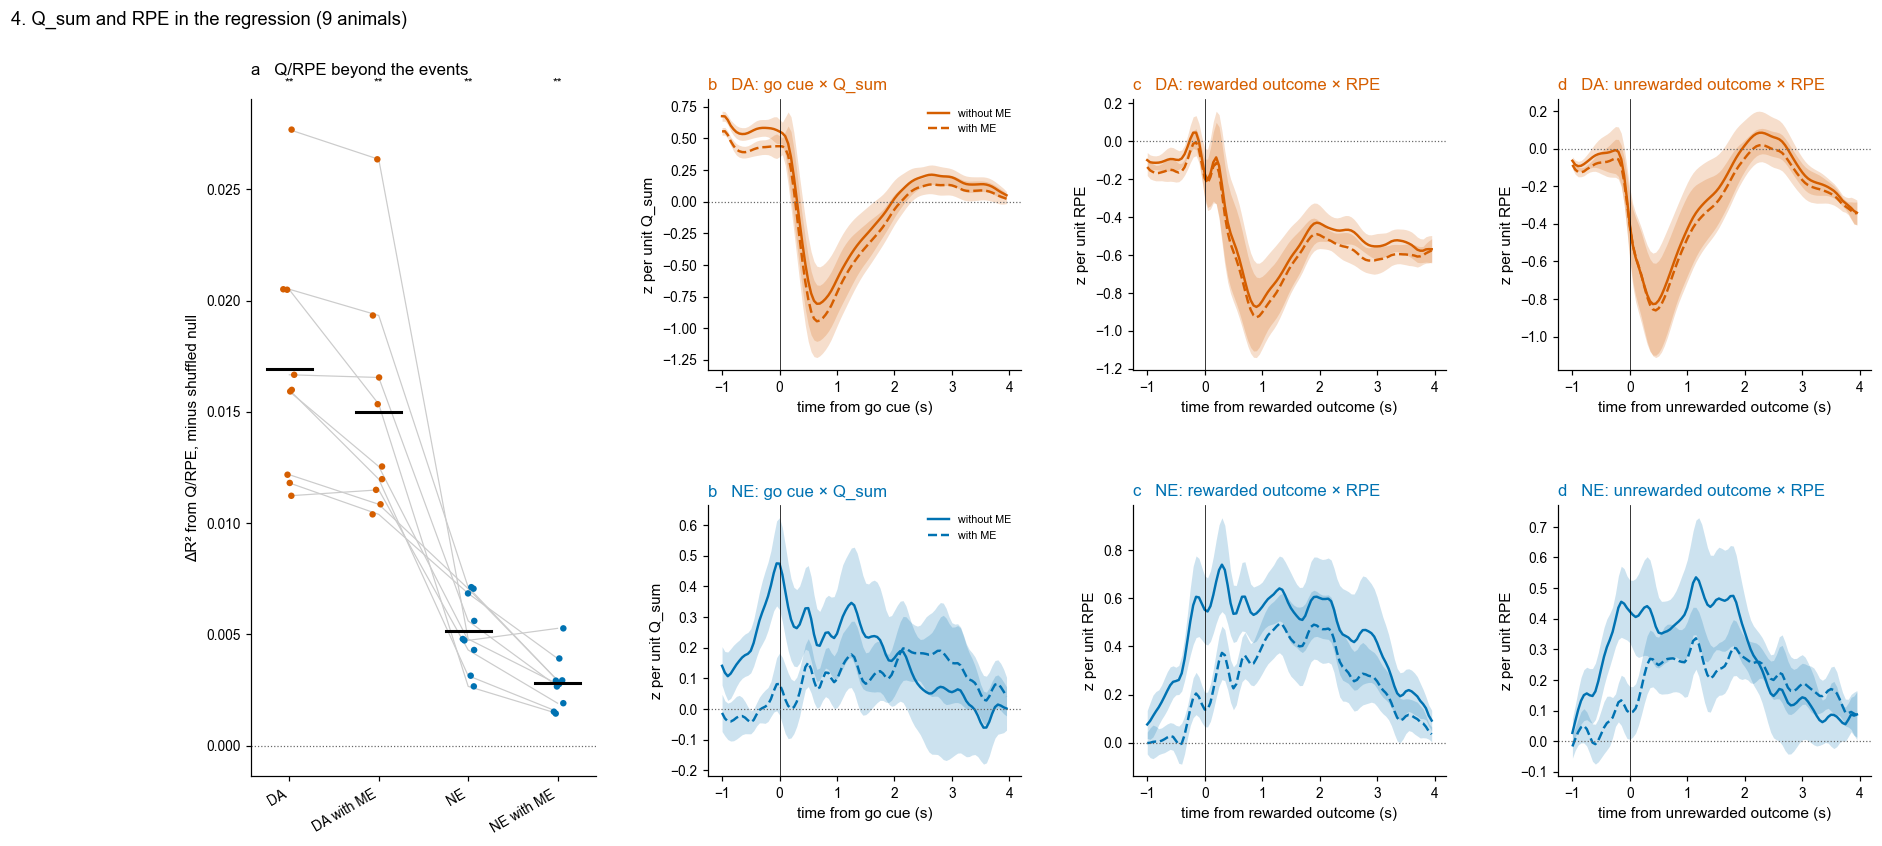

── DA ΔR² from Q/RPE
                       measure    mean      sem       p  n
                da|Q/RPE added  0.0193   0.0018 0.00391  9
           da|Q/RPE added null 0.00232 0.000126 0.00391  9
        da|Q/RPE added vs null  0.0169  0.00177 0.00391  9
        da|Q/RPE added with ME  0.0172  0.00175 0.00391  9
   da|Q/RPE added with ME null 0.00227 0.000123 0.00391  9
da|Q/RPE added with ME vs null   0.015  0.00173 0.00391  9

── NE ΔR² from Q/RPE
                       measure    mean      sem       p  n
                ne|Q/RPE added 0.00762 0.000552 0.00391  9
           ne|Q/RPE added null 0.00248 9.34e-05 0.00391  9
        ne|Q/RPE added vs null 0.00514  0.00055 0.00391  9
        ne|Q/RPE added with ME 0.00439 0.000334 0.00391  9
   ne|Q/RPE added with ME null 0.00157 0.000132 0.00391  9
ne|Q/RPE added with ME vs null 0.00282 0.000402 0.00391  9



In [11]:
fig = plt.figure(figsize=(19, 8))
gs = GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.35, top=0.88, width_ratios=[1.1, 1, 1, 1])
ax = fig.add_subplot(gs[:, 0])
cols = [f"{s}|Q/RPE added{w} vs null" for s in SIG for w in ("", " with ME")]
pu.strip_by_measure(ax, r2_animal, cols, [f"{s.upper()}{w}" for s in SIG for w in ("", " with ME")],
                    [SIG_COLOR[s] for s in SIG for _ in range(2)],
                    "ΔR² from Q/RPE, minus shuffled null", title="a   Q/RPE beyond the events", rng=rng)
for r, s in enumerate(SIG):
    for c, e in enumerate(VALUE_EVENTS):
        ax = fig.add_subplot(gs[r, c + 1])
        for fit, ls, lab in (("task", "-", "without ME"), ("me", "--", "with ME")):
            pu.plot_mean_sem(ax, KERNEL_T, animal_kernels(s, "events + Q/RPE", fit, e), SIG_COLOR[s],
                             lab, ls=ls)
        ax.axvline(0, color="k", lw=0.5)
        ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
        ax.set_title(f"{'bcd'[c]}   {s.upper()}: {e}", loc="left", color=SIG_COLOR[s])
        ax.set_xlabel(f"time from {e.split(' × ')[0]} (s)")
        ax.set_ylabel("z per unit " + e.split(" × ")[1])
        if c == 0:
            ax.legend(fontsize=7)
        style_ax(ax)
fig.suptitle(f"4. Q_sum and RPE in the regression ({N_ANIMALS} animals)", x=0.01, ha="left")
save_fig(fig, "fip_09_4_value", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()
for s in SIG:
    report(f"{s.upper()} ΔR² from Q/RPE", r2_animal,
           [f"{s}|Q/RPE added{w}{suf}" for w in ("", " with ME") for suf in ("", " null", " vs null")])

## 5. Each model in one session

The session whose NE ΔR² from ME (beyond *events + licks*) is closest to the median, 30 s from the
middle of the session. **a** task events (tick height on the outcome and go-cue rows: the trial's
RPE and Q_sum) and ME; **b, d** NE and DA observed with the task-only predictions of the three
models; **c, e** the same with ME.

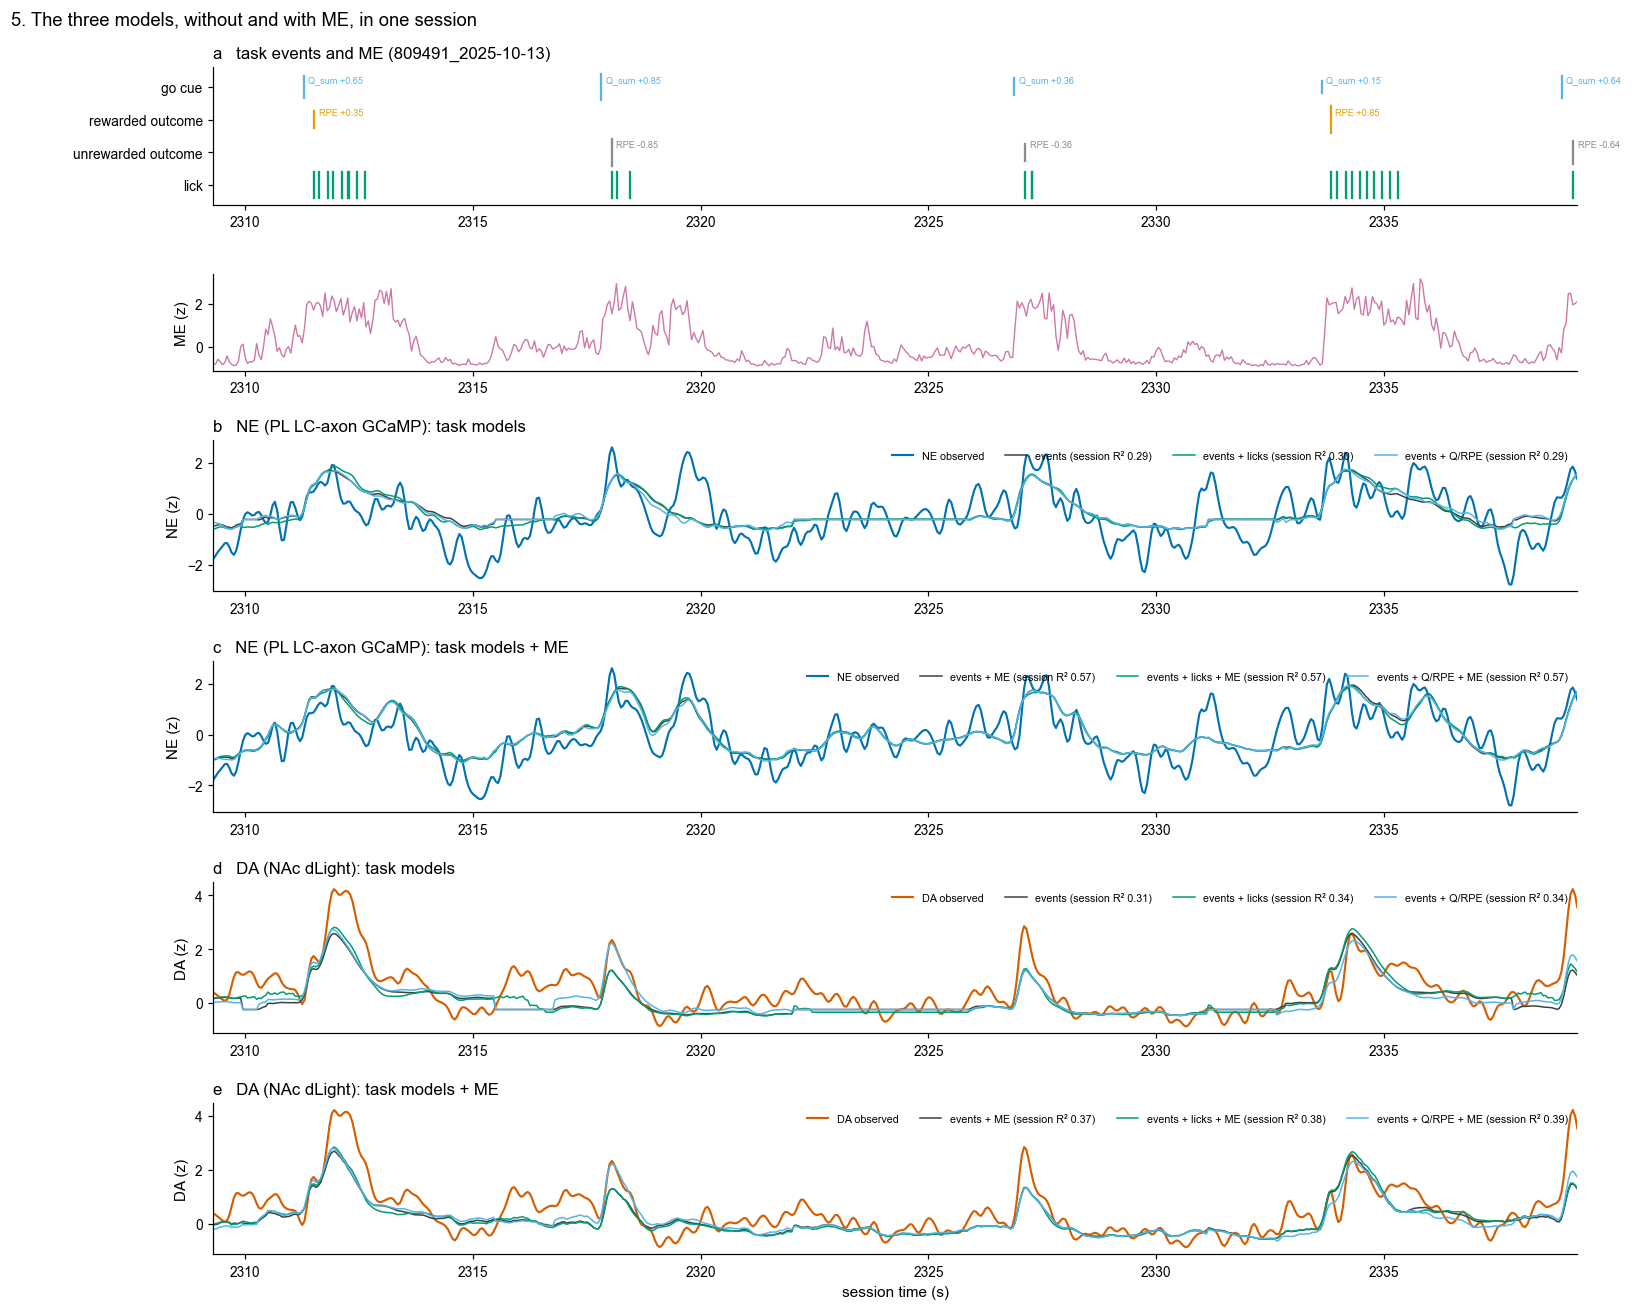

In [12]:
d_r2 = r2_sess["ne|ME added to events + licks"].to_numpy()
ex_i = int(np.argmin(np.abs(d_r2 - np.median(d_r2))))
ex, exb = pairs[ex_i], beta_rows[ex_i]
t = ex["t0"] + np.arange(len(ex["da"])) / FS
tr = ex["trials"]
cues = tr["goCue_start_time_in_session"].to_numpy()
start = cues[cues >= np.nanmedian(cues)][0] - 2.0
win = (t >= start) & (t < start + WIN_S)
i0, i1 = np.flatnonzero(win)[[0, -1]]
tw = t[i0:i1 + 1]
X_ex = hstack([design(ex)[i0:i1 + 1], fu.lagged_columns(ex["z"]["me"], FS, ME_LAGS_S)[i0:i1 + 1]],
              format="csr")


def predict(sig, model, fit):
    cols = task_cols(MODELS[model])
    if fit == "me":
        cols = np.r_[cols, ME_COLS]
    return X_ex[:, cols] @ exb[(sig, model, fit)]


fig = plt.figure(figsize=(16, 13))
gs = GridSpec(6, 1, figure=fig, height_ratios=[1, 0.7, 1.1, 1.1, 1.1, 1.1], hspace=0.5, top=0.94)
ax0 = ax = fig.add_subplot(gs[0])
responded = (tr["animal_response"] < 2).to_numpy()
rew = tr["earned_reward"].fillna(0).astype(bool).to_numpy() & responded
outc = tr["reward_outcome_time_in_session"].to_numpy()
in_w = lambda x: (x >= tw[0]) & (x <= tw[-1])
rows = [("go cue", cues, tr["Q_sum"].to_numpy(), "Q_sum"),
        ("rewarded outcome", outc[rew], tr["RPE_earned"].to_numpy()[rew], "RPE"),
        ("unrewarded outcome", outc[responded & ~rew], tr["RPE_earned"].to_numpy()[responded & ~rew], "RPE"),
        ("lick", ex["licks"], None, None)]
for y, (name, times, vals, vlab) in enumerate(rows):
    keep = in_w(times)
    for k, x in enumerate(times[keep]):
        h = 0.4 if vals is None or not np.isfinite(vals[keep][k]) else 0.15 + 0.3 * abs(vals[keep][k])
        ax.plot([x, x], [-y - h, -y + h], color=EVENT_COLOR[name], lw=1.5)
        if vals is not None and np.isfinite(vals[keep][k]):
            ax.text(x + 0.1, -y + 0.15, f"{vlab} {vals[keep][k]:+.2f}", fontsize=6, color=EVENT_COLOR[name])
ax.set_yticks(-np.arange(len(rows)))
ax.set_yticklabels([r[0] for r in rows])
ax.set_ylim(-len(rows) + 0.4, 0.6)
ax.set_xlim(tw[0], tw[-1])
ax.set_title(f"a   task events and ME ({ex['session']})", loc="left")
style_ax(ax)
ax = fig.add_subplot(gs[1], sharex=ax0)
ax.plot(tw, ex["z"]["me"][i0:i1 + 1], color=ME_COLOR, lw=0.9)
ax.set_ylabel("ME (z)")
style_ax(ax)

r2_row = r2_sess.iloc[ex_i]
for row, (sig, fit) in enumerate([("ne", "task"), ("ne", "me"), ("da", "task"), ("da", "me")]):
    ax = fig.add_subplot(gs[row + 2], sharex=ax0)
    ax.plot(tw, ex["z"][sig][i0:i1 + 1], color=SIG_COLOR[sig], lw=1.4, label=f"{sig.upper()} observed")
    for m in MODELS:
        lab = m if fit == "task" else f"{m} + ME"
        ax.plot(tw, predict(sig, m, fit), color=MODEL_COLOR[m], lw=1.0,
                label=f"{lab} (session R² {r2_row[f'{sig}|{lab}']:.2f})")
    ax.set_ylabel(f"{sig.upper()} (z)")
    ax.legend(fontsize=7, ncol=4, loc="upper right")
    ax.set_title(f"{'bcde'[row]}   {SIG_LABEL[sig]}: "
                 f"{'task models' if fit == 'task' else 'task models + ME'}", loc="left")
    style_ax(ax)
ax.set_xlabel("session time (s)")
fig.suptitle("5. The three models, without and with ME, in one session", x=0.01, ha="left")
save_fig(fig, "fip_09_5_example", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 6. Supplementary: fitted kernels

Every kernel of every model, session kernels averaged within animal (mean ± SEM over animals), one
figure per signal. Top row: task models alone; bottom row: with ME. Colour: model. Each kernel is that
regressor's response on top of every other one in the same model, so the outcome kernels of
*events* carry the licking that *events + licks* gives to the lick kernel. The ME filter is the
response per 1 z of ME at each lag (+ lag: signal after ME).

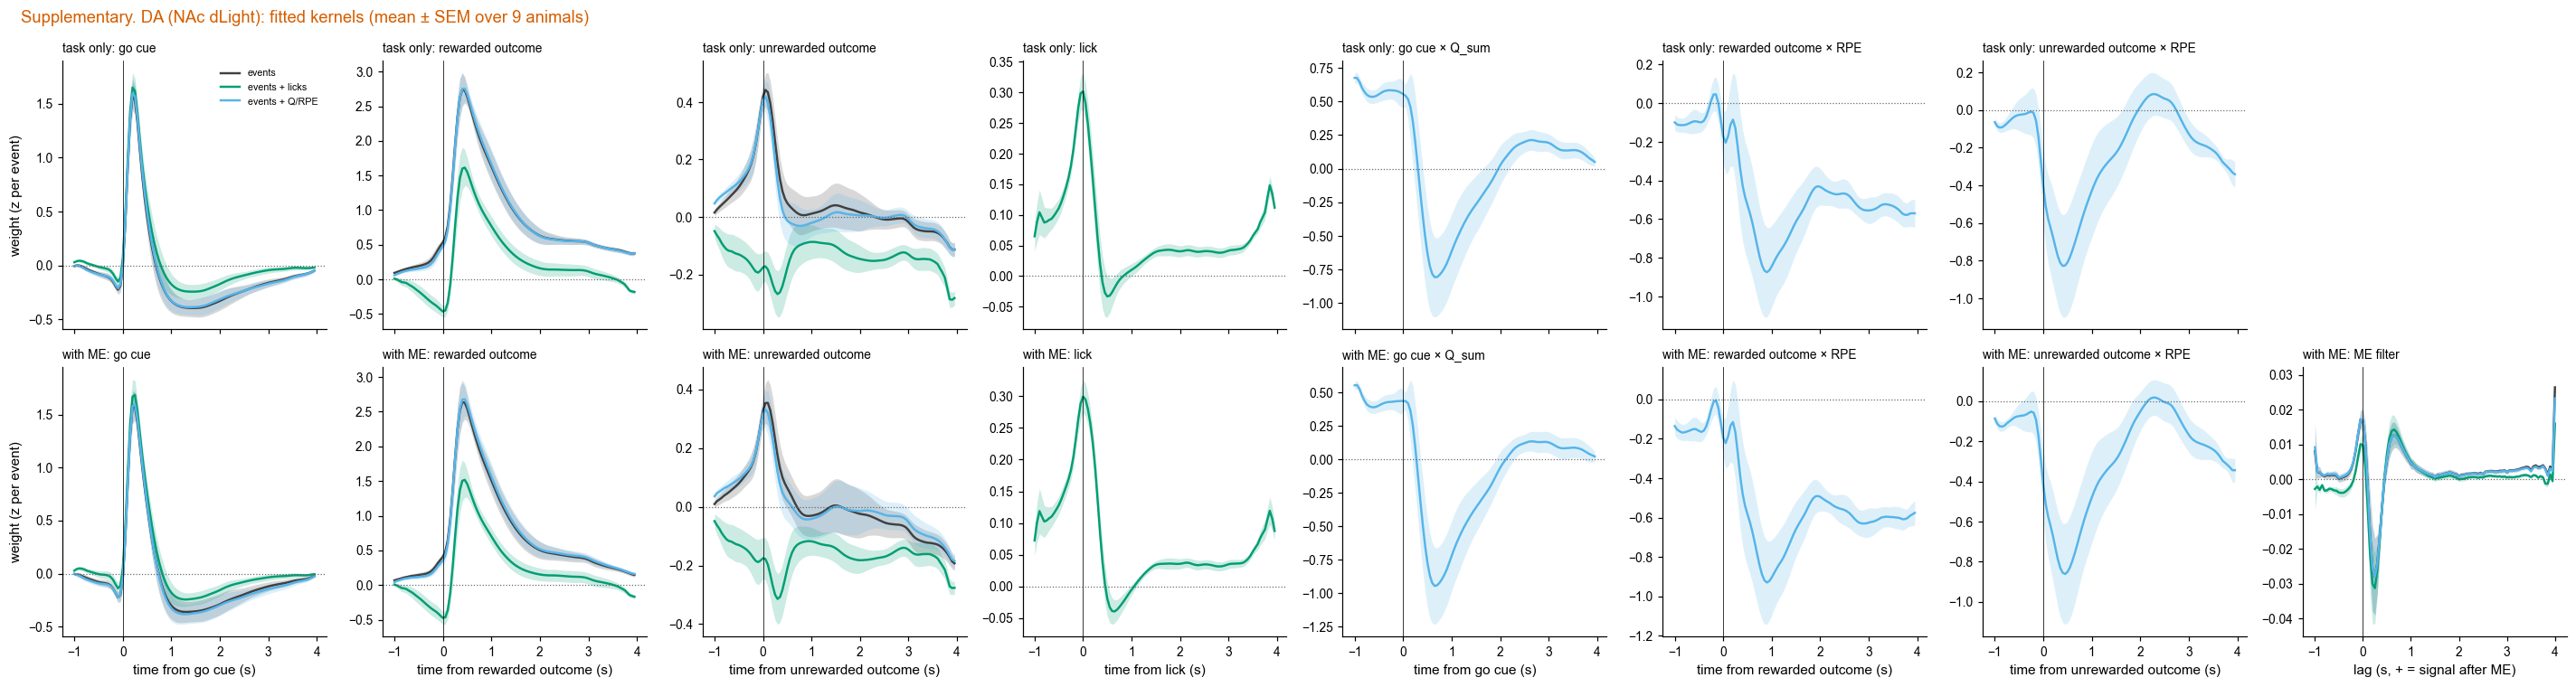

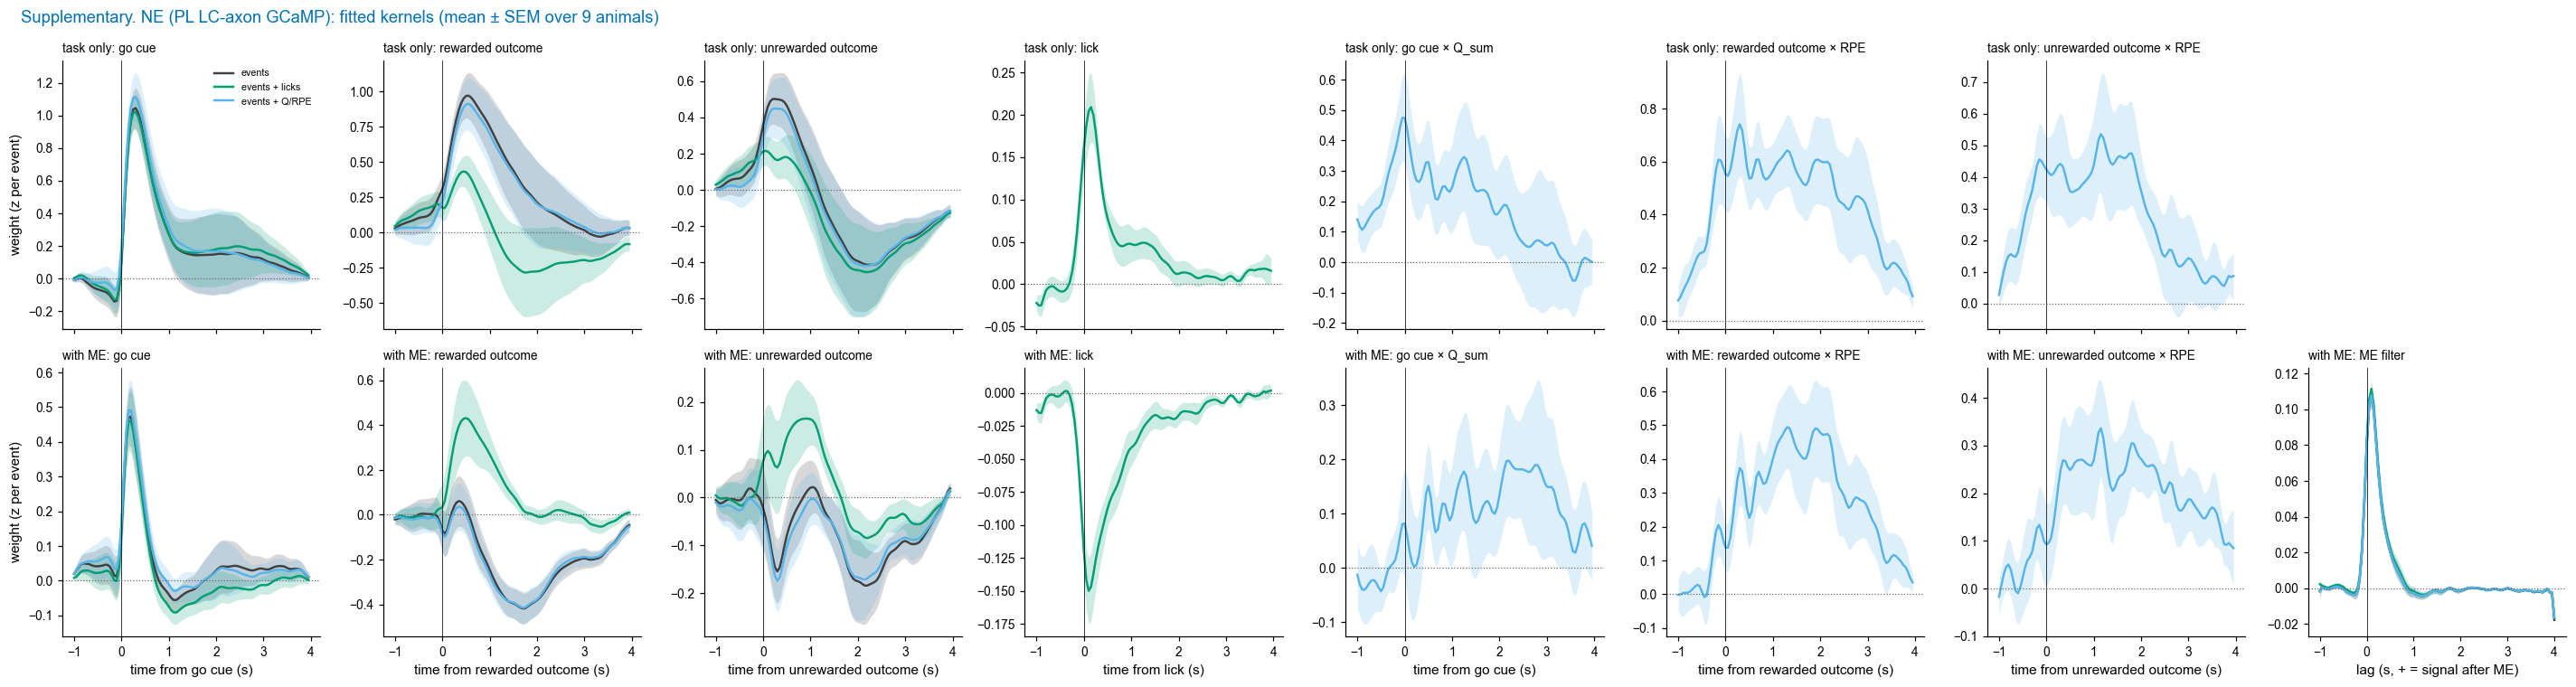

In [13]:
KERNEL_NAMES = ALL_EVENTS + ["ME"]
for s in SIG:
    fig, axes = plt.subplots(2, len(KERNEL_NAMES), figsize=(26, 7), sharex="col")
    for r, fit in enumerate(("task", "me")):
        for c, name in enumerate(KERNEL_NAMES):
            ax = axes[r, c]
            x = ME_T if name == "ME" else KERNEL_T
            for m in MODELS:
                k = animal_kernels(s, m, fit, name)
                if k is not None:
                    pu.plot_mean_sem(ax, x, k, MODEL_COLOR[m], m)
            ax.axvline(0, color="k", lw=0.5)
            ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
            ax.set_title(f"{'with ME' if fit == 'me' else 'task only'}: "
                         f"{name if name != 'ME' else 'ME filter'}", loc="left", fontsize=9)
            if r == 1:
                ax.set_xlabel("lag (s, + = signal after ME)" if name == "ME"
                              else f"time from {name.split(' × ')[0]} (s)")
            if c == 0:
                ax.set_ylabel("weight (z per event)")
                if r == 0:
                    ax.legend(fontsize=7)
            style_ax(ax)
        axes[0, -1].set_visible(False)
    fig.suptitle(f"Supplementary. {SIG_LABEL[s]}: fitted kernels (mean ± SEM over {N_ANIMALS} animals)",
                 x=0.01, ha="left", color=SIG_COLOR[s])
    fig.tight_layout()
    save_fig(fig, f"fip_09_S1_kernels_{s}", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

## 7. Numbers

One row per measure: mean over animals, Wilcoxon p against zero, animals positive.

In [14]:
def row(section, measure, col):
    v = r2_animal[col]
    m, p, n = st.wilcoxon_animals(v)
    return dict(section=section, measure=measure, mean=round(m, 3), p=round(p, 4),
                animals_positive=f"{int((v > 0).sum())}/{n}")


S = []
for s in SIG:
    S += [row("1", f"{s.upper()} R² {c}", f"{s}|{c}") for c in R2_COLS]
    S += [row("2", f"{s.upper()} ME added to {m} ({lab}), vs null", f"{s}|ME added to {m}{span} vs null")
          for span, lab in (("", "−1…4 s"), (" short", "−1…2 s")) for m in MODELS]
    S += [row("3", f"{s.upper()} licks added{w}", f"{s}|licks added{w}") for w in ("", " with ME")]
    S += [row("4", f"{s.upper()} Q/RPE added{w}, vs null", f"{s}|Q/RPE added{w} vs null")
          for w in ("", " with ME")]
numbers = pd.DataFrame(S)
numbers

,section,measure,mean,p,animals_positive
0,1,DA R² ME only,0.167,0.0039,9/9
1,1,DA R² events,0.398,0.0039,9/9
2,1,DA R² events + ME,0.432,0.0039,9/9
3,1,DA R² events + licks,0.453,0.0039,9/9
4,1,DA R² events + licks + ME,0.474,0.0039,9/9
5,1,DA R² events + Q/RPE,0.417,0.0039,9/9
6,1,DA R² events + Q/RPE + ME,0.449,0.0039,9/9
7,2,"DA ME added to events (−1…4 s), vs null",0.033,0.0039,9/9
8,2,"DA ME added to events + licks (−1…4 s), vs null",0.019,0.0039,9/9
9,2,"DA ME added to events + Q/RPE (−1…4 s), vs null",0.031,0.0039,9/9
